In [31]:
import numpy as np
from scipy.signal import resample
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import welch
plt.rcParams.update({'font.size': 16})
#mpl.rcParams['figure.figsize'] = [10, 5]
#mpl.rcParams['figure.dpi'] = 300

from tqdne.conf import Config
config = Config()
dataset_path = "/store/sdsc/sd28/wforms_GAN_input_v20220805.h5"
dataset_path

'/store/sdsc/sd28/wforms_GAN_input_v20220805.h5'

In [2]:
from tqdne.dataset import SampleDataset
from tqdne.representations import Signal


train_dataset = SampleDataset(config.datasetdir / config.data_train, Signal())
test_dataset = SampleDataset(config.datasetdir / config.data_test, Signal())

#combine train and test datasets
waveforms = np.concatenate([train_dataset.waveforms, test_dataset.waveforms])
features = np.concatenate([train_dataset.features, test_dataset.features])
waveforms.shape, features.shape 

((212598, 3, 5501), (212598, 4))

In [3]:
for i in range(features.shape[-1]):
    print(i)
    print(f'Feature {config.features_keys[i]} --  min: {np.nanmin(features[:, i])}, max: {np.ma.masked_invalid(features[:, i]).max()}, max_inf: {np.max(features[:, i])}, min_inf: {np.min(features[:, i])}')

0
Feature hypocentral_distance --  min: 3.9779791831970215, max: 179.99957275390625, max_inf: 179.99957275390625, min_inf: 3.9779791831970215
1
Feature is_shallow_crustal --  min: 0.0, max: 1.0, max_inf: 1.0, min_inf: 0.0
2
Feature magnitude --  min: 4.5, max: 9.083505630493164, max_inf: 9.083505630493164, min_inf: 4.5
3
Feature vs30 --  min: -1.0, max: 2100.0, max_inf: 2100.0, min_inf: -1.0


In [4]:
print("Number of shallow crustal envents: ", int(np.sum(features[:, 1])))
# idx = np.where(features[:,1] == 1)
# waveforms = waveforms[idx[0],:,:]
# features = features[idx[0],:]
waveforms.shape, features.shape

Number of shallow crustal envents:  52076


((212598, 3, 5501), (212598, 4))

In [5]:
# define distance bins
dist_bins = np.array([0, 30, 50, 70, 90, 110, 150, 170])
mag_bins = np.array([4.5, 5, 5.5, 6.0, 6.5, 7, 7.5, 8])
imag = 5
imag = [5, 0, 2, 4, 6]
imag = 3
# divide samples in dist_bins
dist_bins_samples = []
mag_bins_samples = []
waveforms_samples = []
is_shallow_crustal_samples = []
vs30_samples = []

max_num = 1000
for i in range(len(dist_bins) - 1):
    mask1 = (features[:, 0] >= dist_bins[i]) & (features[:, 0] < dist_bins[i + 1])
    mask2 = (features[:, 2] >= mag_bins[imag]) & (features[:, 2] < mag_bins[imag + 1])
    mask3 = (features[:, 3] > 0)
    mask = mask1 & mask2 & mask3
    temp1 = waveforms[mask][:max_num]
    print(temp1.shape)
    waveforms_samples.append(np.nan_to_num((waveforms[mask][:max_num])))
    dist_bins_samples.append(np.nan_to_num((features[mask,0][:max_num])))
    is_shallow_crustal_samples.append(np.nan_to_num((features[mask,1][:max_num])))
    mag_bins_samples.append(np.nan_to_num((features[mask,2][:max_num])))
    vs30_samples.append(np.nan_to_num((features[mask,3][:max_num])))

# convert to array
magnitude = np.round((mag_bins[imag]+mag_bins[imag+1])/2, decimals=1)
print(magnitude)

(76, 3, 5501)
(220, 3, 5501)
(494, 3, 5501)
(787, 3, 5501)
(1000, 3, 5501)
(1000, 3, 5501)
(1000, 3, 5501)
6.2


In [6]:
for i in range(len(dist_bins)-1):
    print(waveforms_samples[i].shape)

(76, 3, 5501)
(220, 3, 5501)
(494, 3, 5501)
(787, 3, 5501)
(1000, 3, 5501)
(1000, 3, 5501)
(1000, 3, 5501)


## Generating waveform

In [7]:
import numpy as np
import torch
import os

from pathlib import Path
from tqdne.utils import *
from tqdne.conf import Config
import pickle

/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


In [8]:
dataset_folder = "gm0/model/"
model_path_str = dataset_folder + "ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128"
print(model_path_str)
import os
os.getcwd()

gm0/model/ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128


'/users/kpalguna'

In [9]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.empty_cache()
else: 
    device = torch.device('cpu')

torch.cuda.is_available(), device

(True, device(type='cuda'))

2024-06-03 10:34:09 - root - INFO - Last checkpoint is : gm0/model/ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128/name=0_epoch=91-val_loss=0.01.ckpt
/users/kpalguna/miniconda3/envs/tqdne/lib/python3.11/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


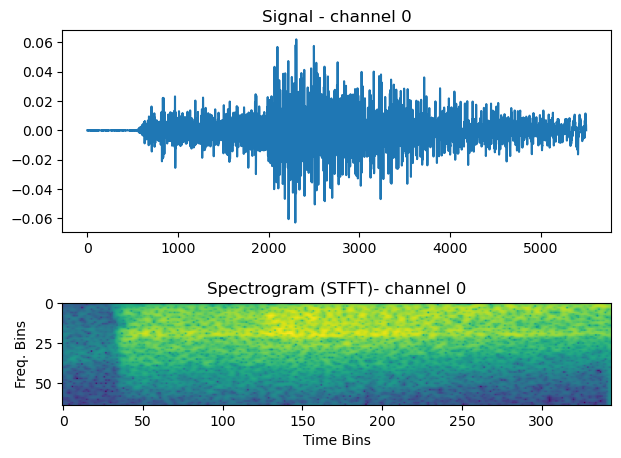

Model: LightningDiffusion
Number of learnable parameters: 38139459
Model size: 458.24 MB
UNet scheme: 
 base num. channels: 32 
 channel multipliers (down/up blocks): (1, 2, 4, 8) 
 num. ResBlocks per down/up block: 2 
 use Attention: True 
 conv. kernel size: 5 
Diffusion prediction type: sample
Learning rate schedule: 
 start: 0.0003 
 scheduler: cosine 
 warmup steps: 500
Batch size: 50
The model was trained on signals with length 5472, as the sampling rate used was 100, whihc is the original sampling rate.
Data representation shape: (1, 3, 64, 344) (batch_size, channels, signal_length)
Data representation name: LogSpectrogram
ckpt file: gm0/model/ddim-pred:sample-2D-downsampling:1_LogSpectrogram-hop_size:16stft_channels:128/name=0_epoch=91-val_loss=0.01.ckpt


In [10]:
model, model_data_repr, ckpt = load_model(Path(model_path_str), use_ddim=False)
model.to(device)
model.eval()
print_model_info(model, model_data_repr, ckpt)

In [11]:
print(magnitude)

6.2


In [97]:
imags = [3]
imag = imags[0]

# divide samples in dist_bins
dist_bins_samples = []
mag_bins_samples = []
waveforms_samples = []
is_shallow_crustal_samples = []
vs30_samples = []

max_num = 1000
for i in range(len(dist_bins) - 1):
    mask1 = (features[:, 0] >= dist_bins[i]) & (features[:, 0] < dist_bins[i + 1])
    mask2 = (features[:, 2] >= mag_bins[imag]) & (features[:, 2] < mag_bins[imag + 1])
    mask3 = (features[:, 3] > 0)
    mask = mask1 & mask2 & mask3
    temp1 = waveforms[mask][:max_num]
    print(temp1.shape)
    waveforms_samples.append(np.nan_to_num((waveforms[mask][:max_num])))
    dist_bins_samples.append(np.nan_to_num((features[mask,0][:max_num])))
    is_shallow_crustal_samples.append(np.nan_to_num((features[mask,1][:max_num])))
    mag_bins_samples.append(np.nan_to_num((features[mask,2][:max_num])))
    vs30_samples.append(np.nan_to_num((features[mask,3][:max_num])))

# convert to array
magnitude = np.round((mag_bins[imag]+mag_bins[imag+1])/2, decimals=1)
print(vs30_samples[3][0])
print(mag_bins_samples[3][0])
print(is_shallow_crustal_samples[3][0])
print(dist_bins_samples[3][0])
print(waveforms_samples[3][0].shape)


vs30 = vs30_samples[3]#[0]
r_hyp = dist_bins_samples[3]#[0]
is_shallow_crustal = is_shallow_crustal_samples[3]#[0]
mag = mag_bins_samples[3]#[0]

cond_input = np.array([
    r_hyp, 
    is_shallow_crustal,
    mag,
    vs30
]).T
# cond_input = cond_input.reshape(1,4)

print(cond_input.shape)

print("Generate waveforms GM0....")
gen_data = generate_data(model, model_data_repr, raw_output=False, cond_input=cond_input,num_samples=100*cond_input.shape[0], device=device)


print("Now saving the waveforms")

i = 3
dataset_folder = "GM0_waveforms/"
bin_save = str(dist_bins[i])+'-'+str(dist_bins[i+1])
with open(dataset_folder + 'shakemap_gm0-stft_'+str(mag)+'-'+bin_save+'2.pkl', 'wb') as f:
    pickle.dump(gen_data, f)
print('Done writing:' + dataset_folder + 'shakemap_gm0-stft_'+str(mag)+'-'+bin_save+'2.pkl')


(76, 3, 5501)
(220, 3, 5501)
(494, 3, 5501)
(787, 3, 5501)
(1000, 3, 5501)
(1000, 3, 5501)
(1000, 3, 5501)
245.56969
6.168122
1.0
78.004234
(3, 5501)
(787, 4)
Generate waveforms GM0....
Batch 1/1574


 26%|██▌       | 26/100 [00:08<00:24,  3.01it/s]


KeyboardInterrupt: 

In [18]:
with open(dataset_folder + 'shakemap_gm0-stft_'+str(mag)+'-'+bin_save+'.pkl', 'rb') as f:
    shakemap_data_gen = pickle.load(f)
    print(shakemap_data_gen['waveforms'].shape, shakemap_data_gen['cond'].shape)

(100, 3, 5472) (100, 4)


In [94]:
# Normalized residual
## Horizonal
wf = waveforms_samples[3][0]
wf_NS = wf[0,:]
wf_EW = wf[1,:]
wf_UD = wf[2,:]
wf_hor = np.sqrt(0.5*( wf_NS**2 + wf_EW**2 ))

waveform = shakemap_data_gen['waveforms']
waveform_EW = waveform[:,1,:]
waveform_NS = waveform[:,0,:]
waveform_UD = waveform[:,2,:]
waveform_hor = np.sqrt(0.5*( waveform_EW**2 + waveform_NS**2 ))

fs = 100
Nf = 256

frequencies, psd_obs = welch(wf_hor, fs, nperseg=Nf)

waveform_hor_update = np.zeros((len(waveform_EW[:,0]), int(Nf/2)+1))
for i in range(len(waveform_hor[:,0])):
    freq, psd_gm0 = welch(waveform_hor[i], fs, nperseg=Nf)
    waveform_hor_update[i,:] = psd_gm0

epsilon = ( np.log(psd_obs) - np.mean(np.log(waveform_hor_update), axis=0) ) / (np.std(np.log(waveform_hor_update), axis=0))


epsilon_mean = epsilon
epsilon_16 = ( np.log(psd_obs) - np.percentile(np.log(waveform_hor_update), 16, axis=0) ) / (np.std(np.log(waveform_hor_update), axis=0))
epsilon_84 = ( np.log(psd_obs) - np.percentile(np.log(waveform_hor_update), 84, axis=0) ) / (np.std(np.log(waveform_hor_update), axis=0))
bar = epsilon_84 - epsilon_16

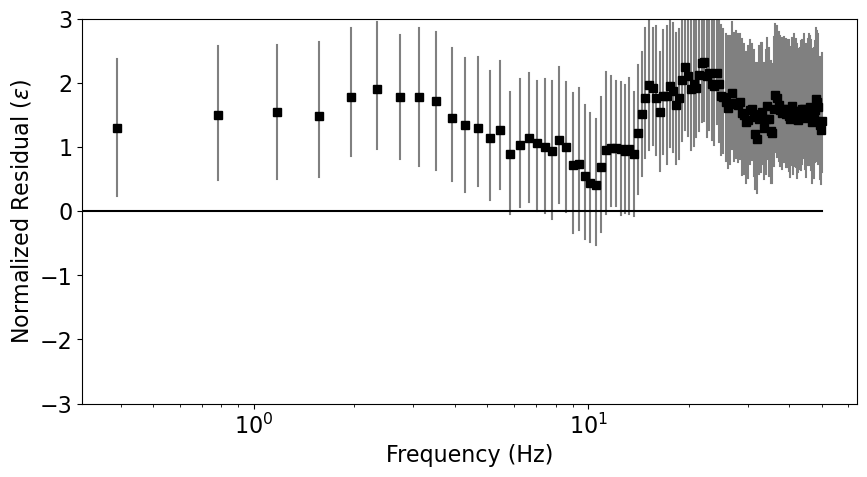

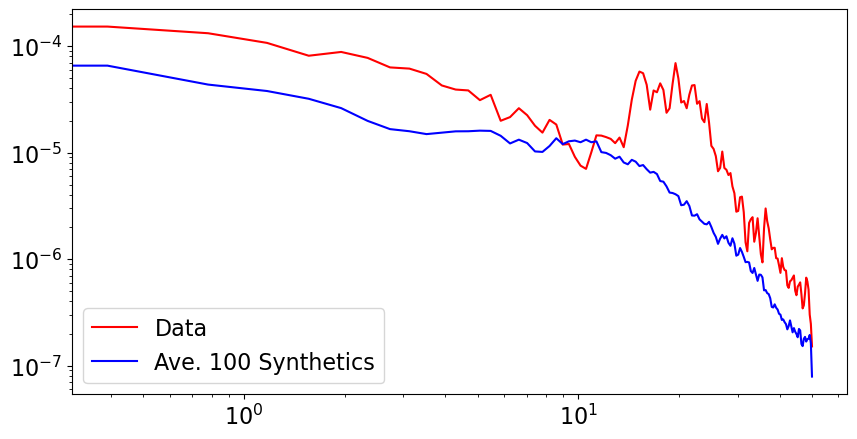

In [95]:
fig = plt.figure(figsize=(10,5))
ax = fig.gca()
for i in range(len(frequencies)):
    ax.semilogx([frequencies[i], frequencies[i]], [epsilon_mean[i], epsilon_84[i]], '-', color='grey')
    ax.semilogx([frequencies[i], frequencies[i]], [epsilon_mean[i], epsilon_16[i]], '-', color='grey')
ax.semilogx(frequencies, epsilon_mean, 's', color='k')
ax.semilogx(frequencies, np.zeros(frequencies.shape), '-', color='k')
ax.set_ylim(-3,3)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"Normalized Residual ($\epsilon$)")

fig = plt.figure(figsize=(10,5))
ax = fig.gca()
ax.loglog(frequencies, psd_obs, "-", color="r", label="Data")
ax.loglog(frequencies, np.mean(waveform_hor_update, axis=0), "-", color="b", label="Ave. 100 Synthetics")
ax.legend()
